In [1]:
import os
import shutil
from datetime import datetime
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

In [3]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

In [4]:
# new_data = {}
# new_data['data'] = data

# save_nested_dict_to_hdf5(data_filename, new_data)

In [5]:
data_filename = 'current_correlations_data.h5'

data = load_nested_dict_from_hdf5(data_filename)

In [6]:
print_tree(data, max_level=3)

data
- coupling_point_2
- - highest
- coupling_point_4
- - highest
- - lowest
simulation
- highest
- - no_dephasing


# 1. Plot Single Coupling Point and Sim

In [7]:
coupling_point = 'coupling_point_2'
coupling_point = 'coupling_point_4'

eigenstate = 'highest'
# eigenstate = 'lowest'

dephasing = 'no_dephasing'

In [8]:
correlation_pairs = []

for i in range(1, 6):
    for j in range(i+2, 8):
        correlation_pairs.append(((i,i+1),(j,j+1)))

print(correlation_pairs)
print(len(correlation_pairs))


config_filename = 'current_correlations_config.json'

with open(config_filename, 'r') as f:
    config = json.load(f)

coupling_point_config = config[coupling_point]
simulation_config = coupling_point_config['simulation_config']

times = np.linspace(simulation_config['time_start'], simulation_config['time_stop'], simulation_config['time_num_points'])


[((1, 2), (3, 4)), ((1, 2), (4, 5)), ((1, 2), (5, 6)), ((1, 2), (6, 7)), ((1, 2), (7, 8)), ((2, 3), (4, 5)), ((2, 3), (5, 6)), ((2, 3), (6, 7)), ((2, 3), (7, 8)), ((3, 4), (5, 6)), ((3, 4), (6, 7)), ((3, 4), (7, 8)), ((4, 5), (6, 7)), ((4, 5), (7, 8)), ((5, 6), (7, 8))]
15


### 1.1 Plot Current Correlation vs Time

In [9]:
# correlation_pairs = []

# d = 2
# correlation_pairs.append(((1,2),(3,4)))
# correlation_pairs.append(((2,3),(4,5)))
# correlation_pairs.append(((3,4),(5,6)))
# correlation_pairs.append(((4,5),(6,7)))
# correlation_pairs.append(((5,6),(7,8)))

# d = 3
# correlation_pairs.append(((1,2),(4,5)))
# correlation_pairs.append(((2,3),(5,6)))
# correlation_pairs.append(((3,4),(6,7)))
# correlation_pairs.append(((4,5),(7,8)))

# d = 4
# correlation_pairs.append(((1,2),(5,6)))
# correlation_pairs.append(((2,3),(6,7)))
# correlation_pairs.append(((3,4),(7,8)))

# d = 5
# correlation_pairs.append(((1,2),(6,7)))
# correlation_pairs.append(((2,3),(7,8)))

# d = 6
# correlation_pairs.append(((1,2),(7,8)))


In [10]:
def plot_triangle_lattice_8q(ax, highlight_rungs=None, annotate_rungs=None, node_size=300, base_edge_color="0.5", highlight_color="C1"):
    """
    highlight_rungs is a list of tuples like [(1,5), (2,7)].
    annotate_rungs is a list of tuples like [((1,5),"annotate text"), ((2,7),"annotate text")].
    """
    if highlight_rungs is None:
        highlight_rungs = []
    if annotate_rungs is None:
        annotate_rungs = []

    highlight_set = {tuple(sorted(e)) for e in highlight_rungs}
    annotate_dict = {tuple(sorted(e[0])): e[1] for e in annotate_rungs}
    positions = {
        1: (0, 1), 3: (1, 1), 5: (2, 1), 7: (3, 1),
        2: (0.5,   0), 4: (1.5,   0), 6: (2.5,   0), 8: (3.5,   0),
    }

    horizontal_rungs = [(1,3), (3,5), (5,7), (2,4), (4,6), (6,8)]
    diagonal_rungs = [(1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8)]
    all_edges = diagonal_rungs + horizontal_rungs

    # Draw edges
    for (i, j) in all_edges:
        x0, y0 = positions[i]
        x1, y1 = positions[j]
        edge = tuple(sorted((i, j)))

        if edge in highlight_set:
            color = highlight_color
            lw, z = 3, 3
        else:
            color = base_edge_color
            lw, z = 1.2, 1
            
        # print(f"drawing edge {edge}")
        if edge in annotate_dict:
            # print(f"annotating edge {edge, annotate_dict[edge]}")
            if edge[0] % 2 != 0:
                ax.annotate( str(annotate_dict[edge]), xy=((x0 + x1) / 2.0, (y0 + y1) / 2.0), xytext=(6, -1),
                    textcoords="offset points", ha="left", va="top", fontsize=8)
            else:
                ax.annotate( str(annotate_dict[edge]), xy=((x0 + x1) / 2.0, (y0 + y1) / 2.0), xytext=(6, 1),
                    textcoords="offset points", ha="left", va="bottom", fontsize=8)

        ax.plot([x0, x1], [y0, y1], color=color, lw=lw, zorder=z)

    # Draw qubits (nodes)
    xs = [positions[q][0] for q in positions]
    ys = [positions[q][1] for q in positions]
    ax.scatter(xs, ys, s=node_size, facecolor="lightgray", edgecolor="dimgray", linewidth=1, zorder=4)

    ax.set_aspect("equal")
    ax.set_xlim(-0.5, 4.0)
    ax.set_ylim(-0.3, 1.3)
    ax.axis("off")
    return positions, {"horizontal": horizontal_rungs, "diagonal": diagonal_rungs}


In [19]:
def plot_correlation_data_and_sim(
    data,
    coupling_point,
    eigenstate,
    correlation_pairs,
    plot_lattice=True,
    simulation_config=None,
    nrows=5,
    ncols=3
):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 16))
    axes = np.array(axes)
    axes_flat = axes.flat

    for idx, correlation_pair in enumerate(correlation_pairs):
        if idx >= nrows * ncols:
            break

        ax_main = axes_flat[idx]

        # Extracting and Plotting Actual Data
        correlation_pair_data = data['data'][coupling_point][eigenstate][str(correlation_pair)]
        times = correlation_pair_data['times']
        beamsplitter_time = correlation_pair_data['beamsplitter_time']
        current_correlation = correlation_pair_data['current_correlation']
        current_correlation_value = correlation_pair_data['current_correlation_value']

        # main time-current plot
        ax_main.plot(times, current_correlation, linestyle='', marker='o', markersize=3, label="data")
        ax_main.axvline(beamsplitter_time, color='r', alpha=0.4, linestyle='--', label='Beamsplitter Time (data)')
        
        # Plotting Simulation Data
        if simulation_config is not None:
            try:
                sim_correlation_pair_data = data['simulation'][eigenstate]['no_dephasing'][coupling_point][str(correlation_pair)]
                sim_current_correlation = sim_correlation_pair_data['current_correlation_BS']
                beamsplitter_time_sim = sim_correlation_pair_data['beamsplitter_time']*1e3
    
                sim_times = np.linspace(simulation_config['time_start'], simulation_config['time_stop'], simulation_config['time_num_points']) * 1e3
                ax_main.plot(sim_times, sim_current_correlation, linestyle='-', markersize=3, alpha=0.5, label="sim")
                ax_main.axvline(beamsplitter_time_sim, color='b', alpha=0.4, linestyle='--', label='Beamsplitter Time (sim)')

            except Exception as e:
                print(f"Failed to extract sim data: {e}")
        
        # Mark Data beam splitter point
        ax_main.annotate(
            f'{current_correlation_value:.3f}',
            xy=(beamsplitter_time, current_correlation_value),
            xytext=(beamsplitter_time + 5, current_correlation_value + 0.05),
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3),
            fontsize=7
        )
        
        # Plot triangle lattice
        if plot_lattice:
            # inset: triangle lattice for this rung pair
            # Position: [x0, y0, width, height] in axes fraction coordinates
            inset_ax = ax_main.inset_axes([0.55, 0.0, 0.4, 0.35])
            plot_triangle_lattice_8q(inset_ax, highlight_rungs=[correlation_pair[0], correlation_pair[1]], node_size=70)
            
        ax_main.set_xlabel('Time (ns)')
        ax_main.set_ylabel('Current Correlation')
        ax_main.set_title(f'Rungs {correlation_pair[0]}–{correlation_pair[1]}', fontsize=10)
        ax_main.set_ylim(-20, 20)
        ax_main.legend(fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.show()

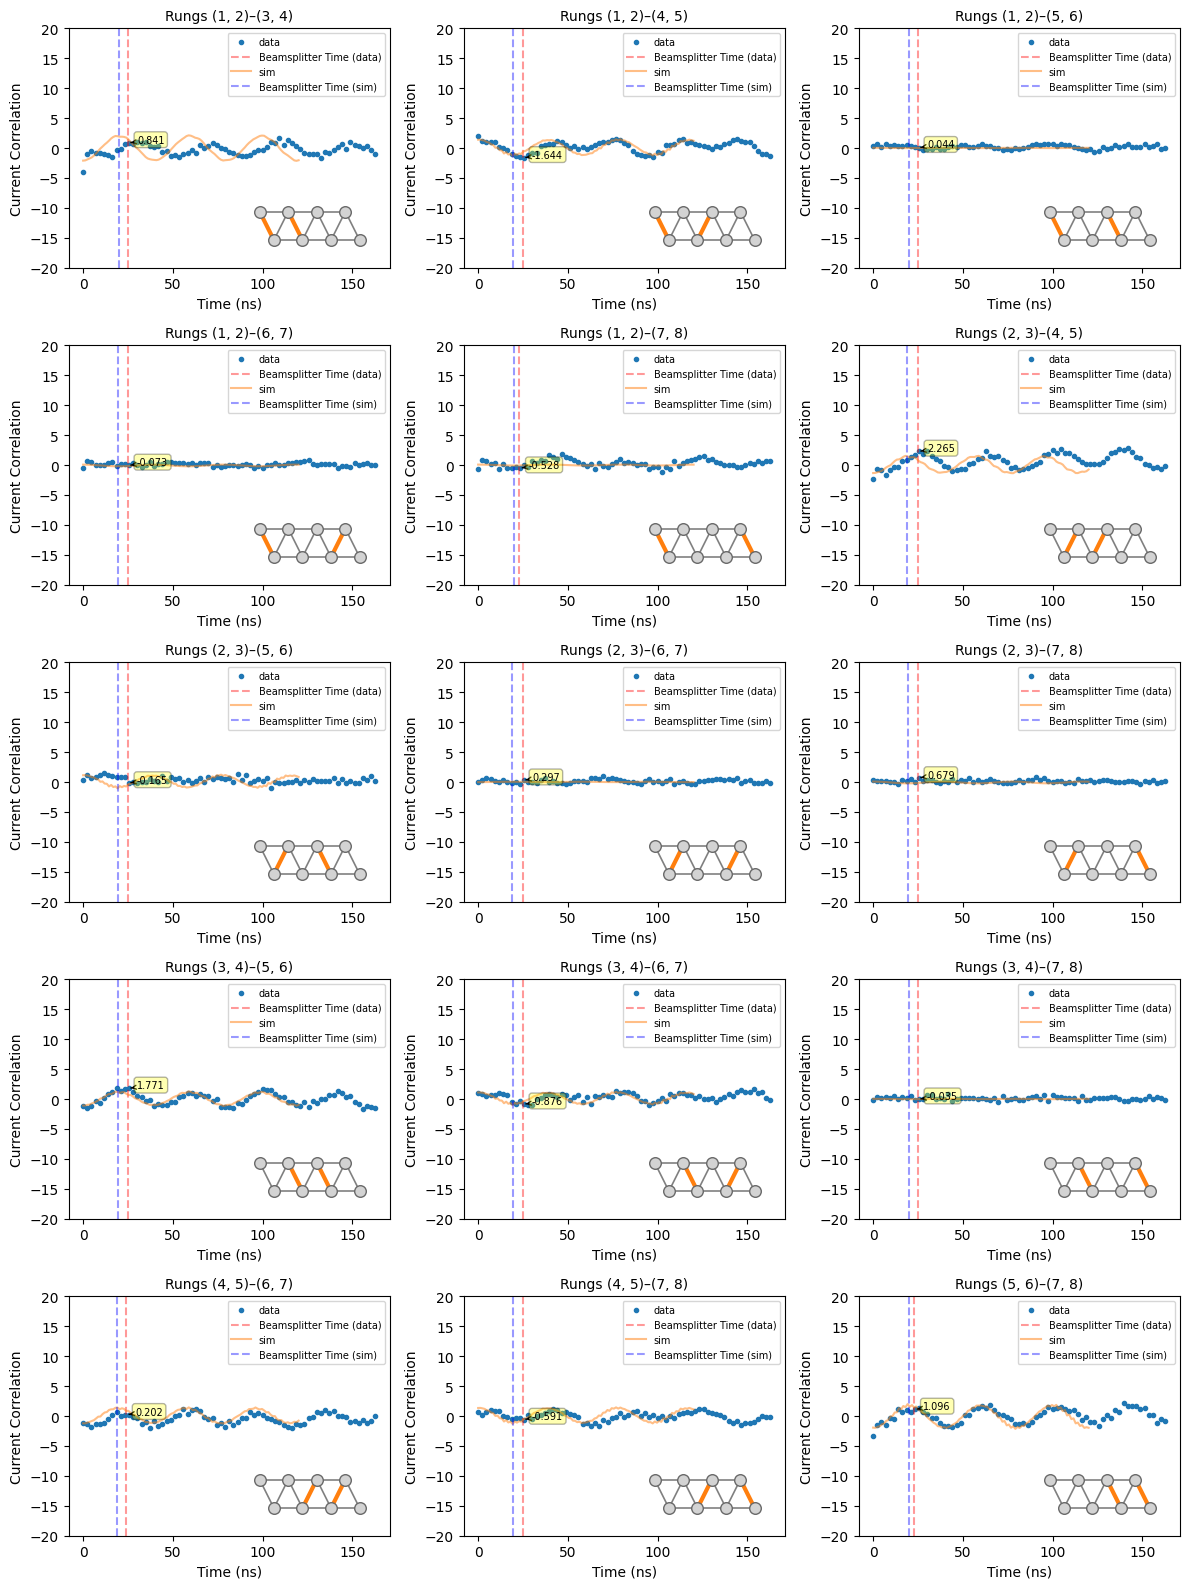

In [20]:
plot_correlation_data_and_sim(
    data                = data,
    coupling_point      = coupling_point,
    eigenstate          = eigenstate,
    correlation_pairs   = correlation_pairs,
    plot_lattice        = True, # False to not plot lattice
    simulation_config   = simulation_config, # None if dont want sim plotted
    nrows               = 5,
    ncols               = 3
)


### 1.2 Plot Current Correlation by distance

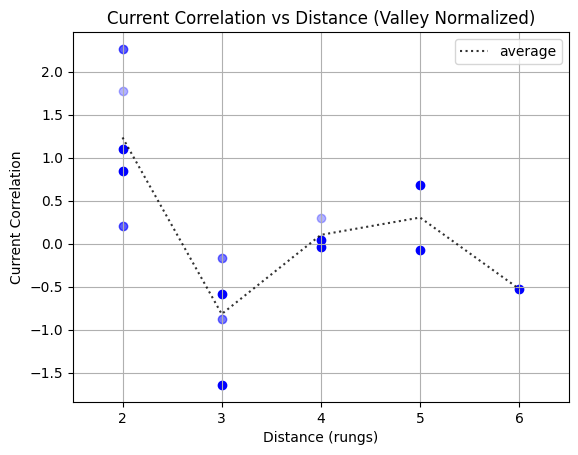

total chiral currnet: 0.2930667019801857


In [21]:
current_correlation_by_distance = {}


for correlation_pair in correlation_pairs:

    correlation_pair_data = data['data'][coupling_point][eigenstate][str(correlation_pair)]

    current_correlation_value = correlation_pair_data['current_correlation_value']

    distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))
    position = (min(correlation_pair[0]) + min(correlation_pair[1])) / 2

    if not distance in current_correlation_by_distance:
        current_correlation_by_distance[distance] = []
    
    current_correlation_by_distance[distance].append((current_correlation_value, position))


distances = []
current_correlation_averages = []

for distance in current_correlation_by_distance:
    distances.append(distance)
    temp_current_correlations = [corr_data[0] for corr_data in current_correlation_by_distance[distance]]
    current_correlation_averages.append(np.mean(temp_current_correlations))

# plot
for distance in current_correlation_by_distance:
    temp_current_correlations = [corr_data[0] for corr_data in current_correlation_by_distance[distance]]
    temp_positions = [corr_data[1] for corr_data in current_correlation_by_distance[distance]]
    
    def valley_normalize(arr, floor=0.3):
        arr = np.array(arr, dtype=float)
        med = np.median(arr)
        d = np.abs(arr - med)
        dmax = d.max()
        if dmax == 0: # for the case where arr is just one value or all the same
            return np.ones_like(arr)
        normalized = d / dmax
        return floor + (1 - floor) * normalized
    
    alpha_values = valley_normalize(temp_positions)
    
    for current_corr_value, alpha_value, pos in zip(temp_current_correlations, alpha_values, temp_positions):
        plt.scatter([distance], current_corr_value, color='b', alpha=alpha_value)
        # plt.annotate(f'{pos}', xy=(distance + 0.1, current_corr_value))

plt.plot(distances, current_correlation_averages, linestyle=':', color='black', alpha=0.8, label='average')

plt.xlabel('Distance (rungs)')
plt.xticks([2, 3, 4, 5, 6])
plt.ylabel('Current Correlation')
plt.legend()
plt.xlim(1.5, 6.5)
# plt.ylim(100, 400)

plt.grid()
plt.title('Current Correlation vs Distance (Valley Normalized)')
plt.show()
print(f'total chiral currnet: {sum(current_correlation_averages)}')

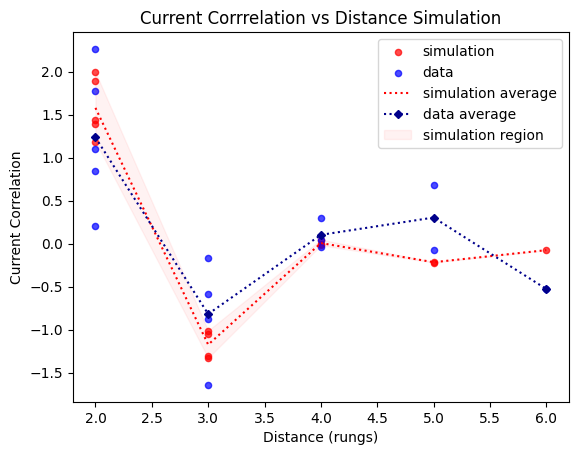

In [23]:
distances = data['simulation'][eigenstate][dephasing][coupling_point]['distances']
distance_to_value_BS_sim = data['simulation'][eigenstate][dephasing][coupling_point]['distance_to_current_correlation_value_BS']
distance_to_value_data = data['data'][coupling_point][eigenstate]['distance_to_current_correlation_value']

current_correlation_BS_averages_sim =  data['simulation'][eigenstate][dephasing][coupling_point]['current_correlation_BS_averages']
current_correlation_averages_data =  data['data'][coupling_point][eigenstate]['current_correlation_averages']

labeled = False
for d in distance_to_value_BS_sim:
    values_sim = distance_to_value_BS_sim[d]
    values_data = distance_to_value_data[d]
    if not labeled:
        label_sim = 'simulation'
        label_data = 'data'
        labeled = True
    else:
        label_sim = None
        label_data = None
    plt.scatter([int(d)]*len(values_sim), values_sim, color='r', alpha=0.7, s=20, label=label_sim)
    plt.scatter([int(d)]*len(values_data), values_data, color='b', alpha=0.7, s=20, label=label_data)

plt.plot(distances, current_correlation_BS_averages_sim, linestyle=':', color='red', label='simulation average')
plt.plot(distances, current_correlation_averages_data, color='darkblue', marker='D', markersize=4, linestyle=':', label='data average')

# For Region Shading
x_vals = sorted(int(d) for d in distance_to_value_BS_sim.keys())
sim_min = []
sim_max = []
data_min = []
data_max = []

for d in distance_to_value_BS_sim:
    vals_sim = np.array(distance_to_value_BS_sim[str(d)])
    vals_data = np.array(distance_to_value_data[d])
    sim_min.append(vals_sim.min())
    sim_max.append(vals_sim.max())
    data_min.append(vals_data.min())
    data_max.append(vals_data.max())

plt.fill_between(x_vals, sim_min, sim_max, color='red', alpha=0.05, label='simulation region')
# plt.fill_between(x_vals, data_min, data_max, color='blue', alpha=0.05, label='data region')

plt.xlabel('Distance (rungs)')
# plt.xticks([2, 3, 4, 5, 6])
plt.ylabel('Current Correlation')
plt.legend()

plt.title('Current Corrrelation vs Distance Simulation')

plt.show()

### 1.3 Plot Correlations vs Position
and make each distance a different color

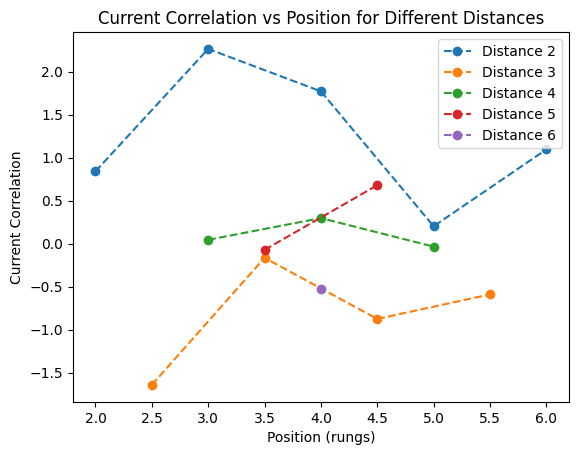

In [24]:
distance_to_current_correlation_vs_position = {}

for i in range(2,7):
    distance_to_current_correlation_vs_position[i] = {'correlation': [], 
                                                      'position': []}


for correlation_pair in correlation_pairs:

    correlation_pair_data = data['data'][coupling_point][eigenstate][str(correlation_pair)]

    current_correlation_value = correlation_pair_data['current_correlation_value']

    distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))

    position = (min(correlation_pair[0]) + min(correlation_pair[1])) / 2

    distance_to_current_correlation_vs_position[distance]['correlation'].append(current_correlation_value)
    distance_to_current_correlation_vs_position[distance]['position'].append(position)


for distance in distance_to_current_correlation_vs_position:
    plt.plot(distance_to_current_correlation_vs_position[distance]['position'],
                distance_to_current_correlation_vs_position[distance]['correlation'],
                marker='o', linestyle='--', label=f'Distance {distance}')
    
plt.xlabel('Position (rungs)')
plt.ylabel('Current Correlation')
plt.legend()
plt.title('Current Correlation vs Position for Different Distances')
plt.show()

### 1.4 Full Summary Plot

In [25]:
def plot_correlation_vs_distance_condensed(
    ax,
    data,
    eigenstate,
    coupling_point,
    dephasing="no_dephasing",
    sim_color="red",
    data_color="blue",
    point_size=20,
    alpha_points=0.7,
    alpha_region=0.05,
    title=None,
):
    """
    Plot: Current Correlation vs Distance for simulation and data,
    including min/max region shading and average curves, onto a given axis `ax`.
    """

    distances = data['simulation'][eigenstate][dephasing][coupling_point]['distances']
    distance_to_value_BS_sim = data['simulation'][eigenstate][dephasing][coupling_point]['distance_to_current_correlation_value_BS']
    distance_to_value_data = data['data'][coupling_point][eigenstate]['distance_to_current_correlation_value']

    current_correlation_BS_averages_sim = data['simulation'][eigenstate][dephasing][coupling_point]['current_correlation_BS_averages']
    current_correlation_averages_data = data['data'][coupling_point][eigenstate]['current_correlation_averages']

    # Scatter Current Correlation points
    labeled = False
    for d in distance_to_value_BS_sim:
        values_sim = distance_to_value_BS_sim[d]
        values_data = distance_to_value_data[d]

        label_sim = 'simulation' if not labeled else None
        label_data = 'data'       if not labeled else None
        labeled = True

        ax.scatter([int(d)] * len(values_sim), values_sim, color=sim_color, alpha=alpha_points, s=point_size, label=label_sim)
        ax.scatter([int(d)] * len(values_data), values_data, color=data_color, alpha=alpha_points, s=point_size, label=label_data)

    # Average lines
    ax.plot(distances, current_correlation_BS_averages_sim, linestyle=':', color=sim_color, label='simulation average')
    ax.plot(distances, current_correlation_averages_data, color=data_color, marker='D', markersize=4, linestyle=':', label='data average')

    # Shaded Region (min/max envelope)
    x_vals = sorted(int(d) for d in distance_to_value_BS_sim.keys())
    sim_min, sim_max = [], []
    data_min, data_max = [], []

    for d in distance_to_value_BS_sim:
        vals_sim = np.array(distance_to_value_BS_sim[d])
        vals_data = np.array(distance_to_value_data[d])
        sim_min.append(vals_sim.min())
        sim_max.append(vals_sim.max())
        data_min.append(vals_data.min())
        data_max.append(vals_data.max())
    
    # Region Shading
    ax.fill_between(x_vals, sim_min, sim_max, color=sim_color, alpha=alpha_region, label='simulation region')
    # ax.fill_between(x_vals, data_min, data_max, color=data_color, alpha=alpha_region, label='data region')
    
    # Zero line
    ax.axhline(0, color='lightgray', linewidth=1, linestyle='-', zorder=-1)

    ax.set_xlabel('Distance (rungs)', fontsize=8)
    ax.set_ylabel('Current Correlation', fontsize=8)
    ax.set_xlim(1.5, 6.5)

    if title is None:
        ax.set_title('Current Correlation vs Distance', fontsize=11)
    else:
        ax.set_title(title)

    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(axis='both', labelsize=8)


In [38]:
def plot_correlation_data_and_sim_condensed(
    data,
    coupling_point,
    eigenstate,
    correlation_pairs,
    corr_vs_time_plot_xlim = (-15,15),
    plot_lattice=True,
    simulation_config=None,
    nrows=5,
    ncols=5
):
    # total rows = nrows of small multiples + 1 summary row
    total_rows = nrows + 1
    
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(
        nrows + 2, ncols,
        height_ratios=[1]*nrows + [0.75] + [3.5]
    )

    # axes for the small time-correlation plots
    axes_small = np.empty((nrows, ncols), dtype=object)
    for r in range(nrows):
        for c in range(ncols):
            axes_small[r, c] = fig.add_subplot(gs[r, c])

    # big combined axis on the bottom row (spans all columns)
    ax_bottom = fig.add_subplot(gs[nrows + 1, :])

    used = np.zeros((nrows, ncols), dtype=bool)
    next_row_for_col = {r: 0 for r in range(nrows)}  # track next free col per row

    # Fill upper panels with time-correlation plots
    for idx, correlation_pair in enumerate(correlation_pairs):
        rung_index = correlation_pair[0][0] - 1
        row_idx = nrows - 1 - rung_index
        if row_idx < 0 or row_idx >= nrows:
            continue

        if row_idx not in next_row_for_col:
            next_row_for_col[row_idx] = 0

        col_idx = next_row_for_col[row_idx]
        if col_idx >= ncols:
            continue

        ax_main = axes_small[row_idx, col_idx]
        used[row_idx, col_idx] = True
        next_row_for_col[row_idx] += 1

        # Extracting and Plotting Actual Data
        correlation_pair_data = data['data'][coupling_point][eigenstate][str(correlation_pair)]
        times = correlation_pair_data['times']
        beamsplitter_time = correlation_pair_data['beamsplitter_time']
        current_correlation = correlation_pair_data['current_correlation']
        current_correlation_value = correlation_pair_data['current_correlation_value']

        # main time-current plot
        ax_main.plot(times, current_correlation, linestyle='', marker='o', markersize=2, label="data")
        ax_main.axvline(beamsplitter_time, color='r', alpha=0.4, linestyle='--', label='Beamsplitter Time')
        
        # Plotting Simulation Data
        if simulation_config is not None:
            try:
                sim_correlation_pair_data = data['simulation'][eigenstate]['no_dephasing'][coupling_point][str(correlation_pair)]
                sim_current_correlation = sim_correlation_pair_data['current_correlation_BS']
                sim_times = np.linspace(
                    simulation_config['time_start'],
                    simulation_config['time_stop'],
                    simulation_config['time_num_points']
                ) * 1000
                ax_main.plot(
                    sim_times,
                    sim_current_correlation,
                    linestyle='-',
                    markersize=2,
                    alpha=0.5,
                    label="sim"
                )
            except Exception as e:
                print(f"Failed to extract sim data: {e}")
        
        # Mark Data beam splitter point
        ax_main.annotate(
            f'{current_correlation_value:.3f}',
            xy=(beamsplitter_time, current_correlation_value),
            xytext=(beamsplitter_time + 20, current_correlation_value + 2),
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3),
            fontsize=7, zorder=10
        )
        
        # Plot triangle lattice inset
        if plot_lattice:
            inset_ax = ax_main.inset_axes([0.55, 0.0, 0.45, 0.45])
            plot_triangle_lattice_8q(inset_ax, highlight_rungs=[correlation_pair[0], correlation_pair[1]], node_size=10)
            
        # Small label in the corner
        ax_main.text(0.95, 0.95, f'{correlation_pair[0]}–{correlation_pair[1]}', transform=ax_main.transAxes, 
                     fontsize=8, ha="right",va="top")

        ax_main.set_ylim(corr_vs_time_plot_xlim[0], corr_vs_time_plot_xlim[1])
        ax_main.tick_params(axis='x', labelsize=6)
        ax_main.tick_params(axis='y', labelsize=6)
        
    # Shared labels for the TOP section
    fig.text(0.50, 0.42, "Time (ns)", ha="center", fontsize=8)
    fig.text(0.08, 0.65, "Current Correlation", va="center", rotation="vertical", fontsize=8)
    
    # Shared legend
    axes_small[0, -1].legend(*axes_small[0, 0].get_legend_handles_labels(), loc="upper left", fontsize=8)

    # Post-processing for upper grid: hide unused axes, shared ticks ----
    for r in range(nrows):
        for c in range(ncols):
            ax = axes_small[r, c]
            if not used[r, c]:
                ax.axis('off')
                continue
            # hide x ticks/labels except on bottom small row
            if r != nrows - 1:
                ax.set_xlabel('')
                ax.set_xticklabels([])
                ax.tick_params(axis='x', which='both', bottom=False, top=False)
            # hide y ticks/labels except on left-most col
            if c != 0:
                ax.set_ylabel('')
                ax.set_yticklabels([])
                ax.tick_params(axis='y', which='both', left=False, right=False)

    # Bottom summary row: correlation vs distance
    plot_correlation_vs_distance_condensed(
        ax_bottom,
        data=data,
        eigenstate=eigenstate,
        coupling_point=coupling_point,
        dephasing="no_dephasing",
        title="Current Correlation vs Distance"
    )

    fig.subplots_adjust(wspace=0.05, hspace=0.1)
    plt.show()


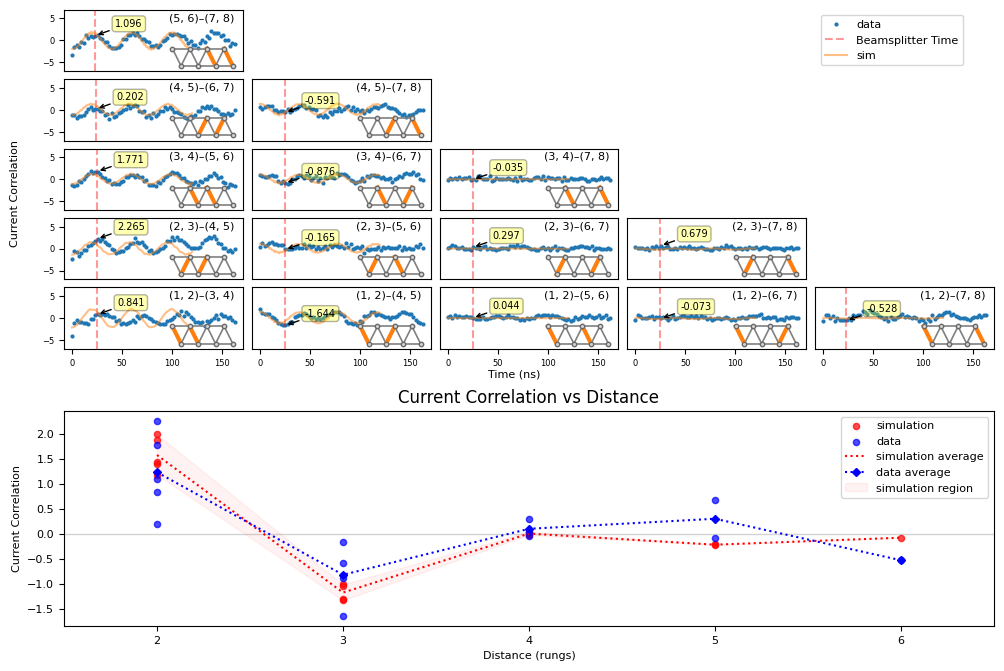

In [39]:
plot_correlation_data_and_sim_condensed(
    data                    = data,
    coupling_point          = coupling_point,
    eigenstate              = eigenstate,
    correlation_pairs       = correlation_pairs,
    corr_vs_time_plot_xlim  = (-7,7),
    plot_lattice            = True,                 # or False
    simulation_config       = simulation_config,    # or None
    nrows                   = 5,
    ncols                   = 5
)
